# Modelo de Previsão de Tickets Totais

### Objetivo

Desenvolver um modelo de previsão para a quantidade total de tickets, utilizando dados históricos e métricas relevantes.
O modelo deve ser capaz de prever a demanda futura de tickets mensal, auxiliando na alocação de recursos e planejamento operacional.

### Passos do Projeto

1. **Análise Exploratória de Dados (EDA)**: Compreender a distribuição dos dados, identificar padrões sazonais e tendências.
2. **Pré-processamento de Dados**: Limpeza dos dados, tratamento de valores ausentes e transformação de variáveis.
3. **Seleção de Modelos**: Avaliar diferentes algoritmos de previsão, como ARIMA, Prophet, LSTM, entre outros.
4. **Treinamento e Validação**: Treinar os modelos selecionados e validar seu desempenho utilizando métricas como MAE, RMSE

In [1]:
import sys
import os
import warnings

import pandas as pd
import numpy as np
import mlflow

# imports modelos
from prophet import Prophet
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from pmdarima import auto_arima

warnings.filterwarnings("ignore")
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, project_root)

/home/eduardo/Documents/Repos/VisionData-6Sem2025ML/.venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
from src.utils.extract_data import get_data

In [3]:
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment("all_tickets_v1")
mlflow.autolog(disable=True)

## Extração de dados

In [4]:
df = get_data("../../sql/all_dates2.sql")

## Tratamento de dados

In [5]:
# Converter para datetime e definir como índice
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.sort_index()

In [6]:
print(f"Shape dos dados: {df.shape}")
print(f"Período: {df.index.min()} até {df.index.max()}")
print("Informações: ", df.info())
print("\nEstatísticas:")
print(df.describe())

Shape dos dados: (2114, 1)
Período: 2020-01-13 00:00:00 até 2025-10-26 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2114 entries, 2020-01-13 to 2025-10-26
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   QtTickets  2114 non-null   int64
dtypes: int64(1)
memory usage: 33.0 KB
Informações:  None

Estatísticas:
         QtTickets
count  2114.000000
mean     42.914380
std      32.240647
min       1.000000
25%      19.000000
50%      33.000000
75%      59.000000
max     177.000000


## Separação entre treino e teste

In [7]:
# quero dividir para primeiro pegar os 20% para teste e 80% para treino

train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [8]:
df = df.asfreq("D")  # força frequência diária
df["QtTickets"] = df["QtTickets"].interpolate()  # preencher valores ausentes

## Funções de avaliação

In [9]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, r2, mape

In [10]:
# AR
def run_ar(train, test):
    model = ARIMA(train, order=(1, 0, 0)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# MA
def run_ma(train, test):
    model = ARIMA(train, order=(0, 0, 1)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# ARMA
def run_arma(train, test):
    model = ARIMA(train, order=(2, 0, 2)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# ARIMA
def run_arima(train, test):
    model = ARIMA(train, order=(2, 1, 2)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# SARIMA
def run_sarima(train, test):
    model = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# SARIMAX
def run_sarimax(train, test, exog_train=None, exog_test=None):
    model = SARIMAX(
        train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12), exog=exog_train
    ).fit()
    preds = model.forecast(steps=len(test), exog=exog_test)
    return model, preds


# Holt-Winters
def run_holt_winters(train, test):
    model = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=12
    ).fit()
    preds = model.forecast(steps=len(test))
    return model, preds


# Prophet
def run_prophet(train, test):
    prophet_df = train.reset_index().rename(columns={"Date": "ds", "QtTickets": "y"})
    model = Prophet()
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    preds = forecast.set_index("ds")["yhat"][-len(test) :]
    return model, preds


# LightGBM
def run_lightgbm(train, test):
    lgbm = LGBMRegressor(n_estimators=1000)
    lgbm.fit(np.arange(len(train)).reshape(-1, 1), train.values)
    preds = lgbm.predict(np.arange(len(train), len(train) + len(test)).reshape(-1, 1))
    return lgbm, preds


def run_auto_arima(train, test):
    # Encontrar os melhores parâmetros automaticamente
    model = auto_arima(
        train,
        start_p=0,
        max_p=5,  # range de p
        start_q=0,
        max_q=5,  # range de q
        d=None,  # deixa o auto_arima determinar d
        seasonal=False,  # considera sazonalidade
        start_P=0,
        max_P=2,  # range de P sazonal
        start_Q=0,
        max_Q=2,  # range de Q sazonal
        D=None,  # deixa o auto_arima determinar D
        m=12,  # período sazonal (12 meses)
        trace=True,  # mostra o progresso
        error_action="ignore",  # ignora erros de convergência
        suppress_warnings=True,  # suprime warnings
        stepwise=True,  # busca stepwise (mais rápido)
        random_state=42,
        n_fits=50,  # máximo de modelos a testar
    )

    print(f"\nMelhor modelo encontrado: {model.order} x {model.seasonal_order}")

    preds = model.predict(n_periods=len(test))
    return model, preds

In [11]:
# dicionario de modelos
model = {
    "AR": run_ar,
    "MA": run_ma,
    "ARMA": run_arma,
    "ARIMA": run_arima,
    "Auto-ARIMA": run_auto_arima,
    "SARIMA": run_sarima,
    "SARIMAX": run_sarimax,
    "Holt-Winters": run_holt_winters,
    "Prophet": run_prophet,
    "LightGBM": run_lightgbm,
}

In [12]:
train["QtTickets"]

Date
2020-01-13    41
2020-01-14    45
2020-01-15    86
2020-01-16    56
2020-01-17    57
              ..
2024-08-25    33
2024-08-26    47
2024-08-27    61
2024-08-28    55
2024-08-29    50
Name: QtTickets, Length: 1691, dtype: int64

In [13]:
# treinar e avaliar cada modelo
list_metrics = {}  # dicionário para armazenar as métricas de cada modelo

for name, func in model.items():
    with mlflow.start_run(run_name=name):
        # treinamento e previsão
        model_fit, preds = func(train["QtTickets"], test["QtTickets"])

        # metricas avaliação
        mae, rmse, r2, mape = evaluate_model(test["QtTickets"], preds)

        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("MAPE", mape)

        # armazenar métricas no dicionário
        list_metrics[name] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

        # parametros de treino
        mlflow.log_param("Train Size", len(train))
        mlflow.log_param("Test Size", len(test))

        # salvar previsoes como artefato .csv e .pkl
        result_df = pd.DataFrame({"Real": test["QtTickets"], "Previsto": preds})
        csv_path = f"../../../data/{name}_predicoes.csv"
        result_df.to_csv(csv_path, index=False)
        model_fit_path = f"../../../models/v1_default_base/{name}_model.pkl"
        pd.to_pickle(model_fit, model_fit_path)

🏃 View run AR at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/ef8874a1a66a4ef6ab7a0547cbe86a8b
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run MA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/685c883d27f9449b9b964c7c872165f2
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run ARMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/e6969a8d57d84d4d811d1876efd6e213
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
🏃 View run ARIMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/606de53c2bfd4097aafc72ea83551bb9
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14655.820, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14641.353, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept 

 This problem is unconstrained.



At iterate    5    f=  4.22204D+00    |proj g|=  1.07509D-01

At iterate   10    f=  4.04643D+00    |proj g|=  3.62766D-02

At iterate   15    f=  3.99274D+00    |proj g|=  1.49663D-02

At iterate   20    f=  3.95209D+00    |proj g|=  3.17217D-02

At iterate   25    f=  3.94879D+00    |proj g|=  3.50656D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     27     36      1     0     0   4.201D-05   3.949D+00
  F =   3.9487893875711340     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
🏃 View run SARIMA at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/8ce879582912467da8a87cc83cd

 This problem is unconstrained.



At iterate    5    f=  4.22204D+00    |proj g|=  1.07509D-01

At iterate   10    f=  4.04643D+00    |proj g|=  3.62766D-02

At iterate   15    f=  3.99274D+00    |proj g|=  1.49663D-02

At iterate   20    f=  3.95209D+00    |proj g|=  3.17217D-02

At iterate   25    f=  3.94879D+00    |proj g|=  3.50656D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     27     36      1     0     0   4.201D-05   3.949D+00
  F =   3.9487893875711340     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
🏃 View run SARIMAX at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/04bad7c18121442f8f4dee5d72

22:58:35 - cmdstanpy - INFO - Chain [1] start processing


🏃 View run Holt-Winters at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/b45228dbe82c45f4a2b1389c75dd30ea
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1


22:58:35 - cmdstanpy - INFO - Chain [1] done processing


🏃 View run Prophet at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/2f9151ae280646288a3f86152c5e8475
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 1691, number of used features: 1
[LightGBM] [Info] Start training from score 33.687759
🏃 View run LightGBM at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1/runs/ed4237b33bba488281a339849f6b39c2
🧪 View experiment at: https://visiondata.ininetech.com.br/mlflow/#/experiments/1


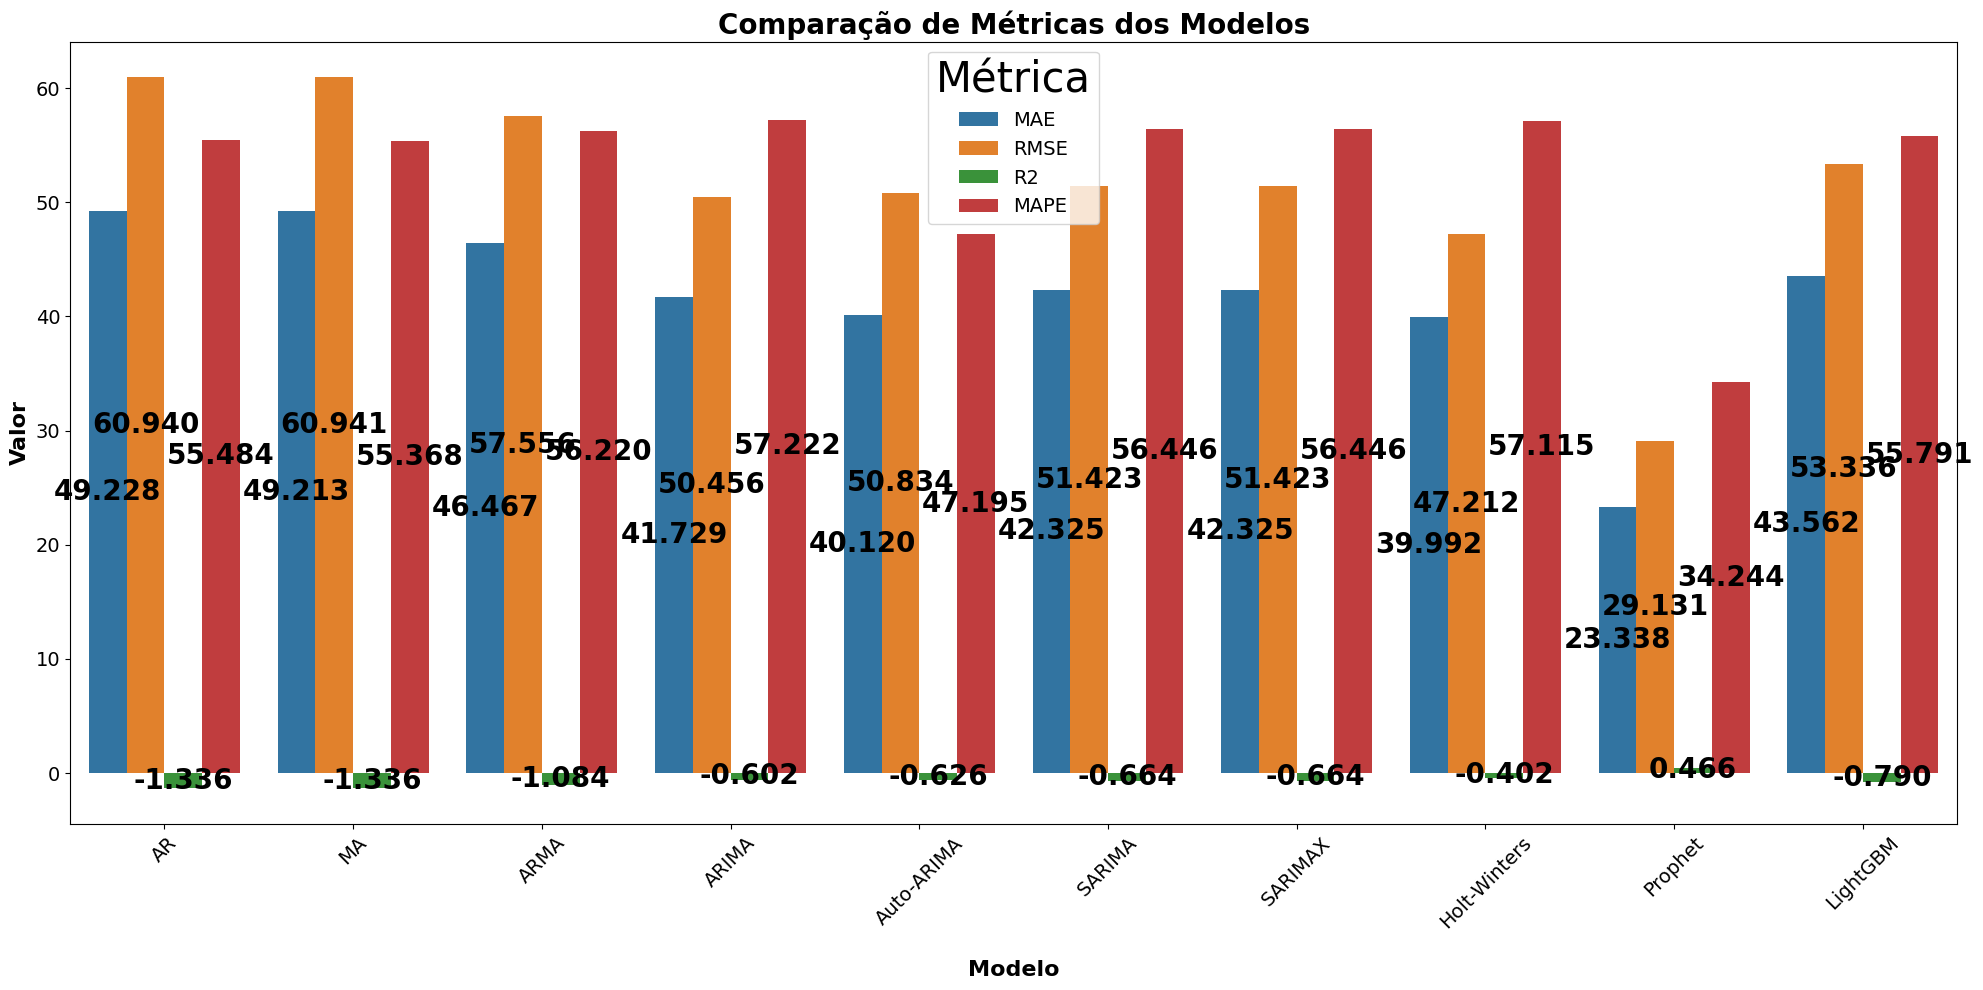

In [14]:
# visualizar métricas de todos os modelos por grafico
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = pd.DataFrame(list_metrics).T
metrics_df = metrics_df.reset_index().melt(
    id_vars="index", var_name="Métrica", value_name="Valor"
)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=metrics_df, x="index", y="Valor", hue="Métrica")

# Adicionar valores nas barras com maior destaque
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        label_type="center",
        fontsize=20,
        color="black",
        weight="bold",
    )

plt.title("Comparação de Métricas dos Modelos", fontsize=20, weight="bold")
plt.xlabel("Modelo", fontsize=16, weight="bold", labelpad=20)
plt.ylabel("Valor", fontsize=16, weight="bold")
plt.legend(title="Métrica", fontsize=14, title_fontsize=30)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()